In [1]:
import numpy as np
import nengo
import matplotlib.pyplot as plt

When connecting neurons with synapses, the information being passed gets attenuated with a low-pass filter.  

However, if we put a recurrent connection on the receiving population, we can compensate for this.  The easiest way is to just implement the dynamics of a much faster low-pass filter.  For example:


C:\Users\terry\anaconda3\envs\py313\Lib\site-packages\nengo\cache.py:624: UserWarning: Decoder cache could not acquire lock and was deactivated.
  warnings.warn("Decoder cache could not acquire lock and was deactivated.")


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

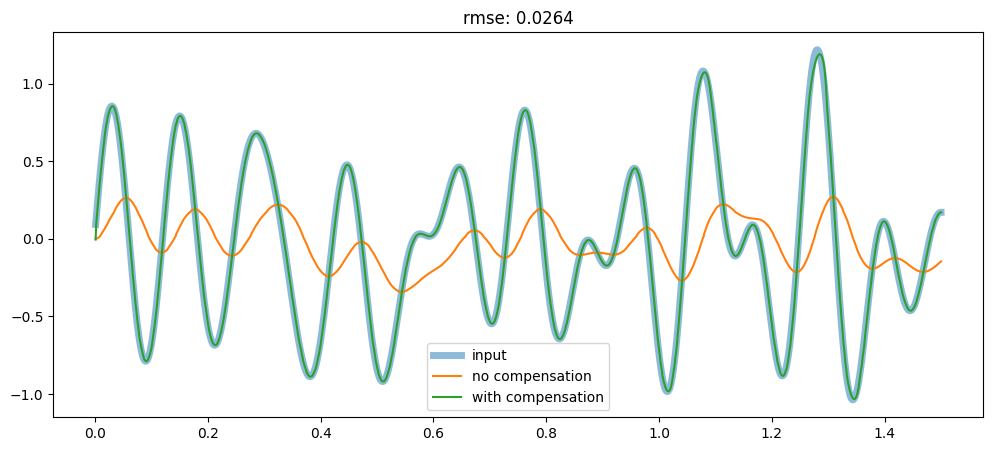

In [2]:
tau = 0.1

model = nengo.Network()
with model:
    stim = nengo.Node(nengo.processes.WhiteSignal(period=5, high=10, rms=0.5, seed=3))
    
    p_stim = nengo.Probe(stim)
    
    a = nengo.Ensemble(n_neurons=100, dimensions=1)
    nengo.Connection(stim, a, synapse=tau)
    p_a = nengo.Probe(a)
    
    tau_desired=0.001
    b = nengo.Ensemble(n_neurons=100, dimensions=1)
    nengo.Connection(stim, b, synapse=tau, transform=tau/tau_desired)
    nengo.Connection(b, b, synapse=tau, transform=(1-tau/tau_desired))
    p_b = nengo.Probe(b)

for ens in model.all_ensembles:
    ens.neuron_type=nengo.LIFRate()    
    
sim = nengo.Simulator(model)
with sim:
    sim.run(1.5)
    
plt.figure(figsize=(12,5))
plt.plot(sim.trange(), sim.data[p_stim], label='input', lw=5, alpha=0.5)
plt.plot(sim.trange(), sim.data[p_a], label='no compensation')
plt.plot(sim.trange(), sim.data[p_b], label='with compensation')
plt.legend()
rmse = np.sqrt(np.mean((sim.data[p_stim]-sim.data[p_b])**2))
plt.title(f'rmse: {rmse:1.4f}')
plt.show()

However, this requires a recurrent connection on the receiving population.  What if we don't want to do this?  Can we adjust the signal being sent such that after it is low-pass filtered, it'll be the value we want?

Let's start with the math approach.  A low-pass filter is $H(s)=1/(s \tau +1)$.  So the inverse of that should be $H(s)=(s \tau +1)/1$.  But that's not a causal system.  So we need to approximate this somehow.  As a horrible first guess, let's approximate it with $H(s)=(s \tau+1)/(0.01s + 1)$.


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

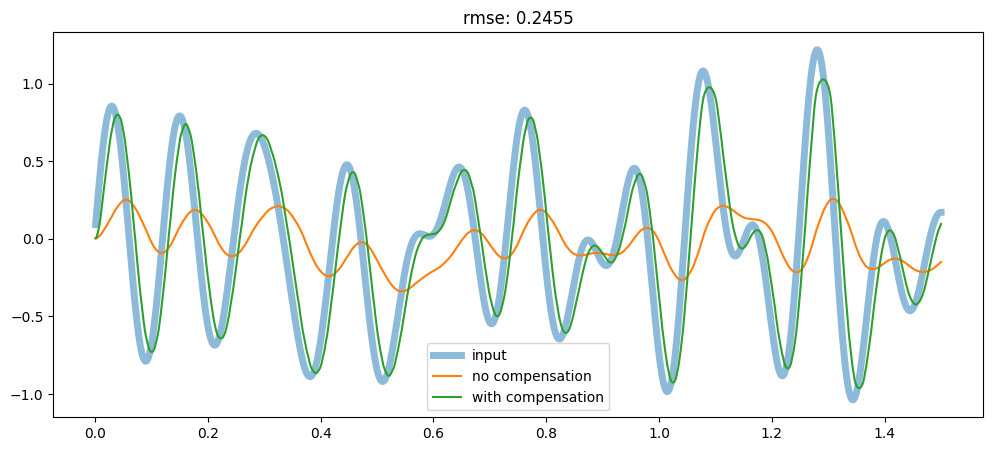

In [3]:
tau = 0.1

model = nengo.Network()
with model:
    stim = nengo.Node(nengo.processes.WhiteSignal(period=5, high=10, rms=0.5, seed=3))
    p_stim = nengo.Probe(stim)
    
    precompensate = nengo.Node(None, size_in=1)
    nengo.Connection(stim, precompensate, synapse=nengo.synapses.LinearFilter([tau,1], [0.01,1]))
    
    a = nengo.Ensemble(n_neurons=100, dimensions=1)
    nengo.Connection(stim, a, synapse=tau)
    p_a = nengo.Probe(a)
    
    c = nengo.Ensemble(n_neurons=100, dimensions=1)
    nengo.Connection(precompensate, c, synapse=tau)
    p_c = nengo.Probe(c)

for ens in model.all_ensembles:
    ens.neuron_type=nengo.LIFRate()
    
sim = nengo.Simulator(model, dt=0.001)
with sim:
    sim.run(1.5)
    
plt.figure(figsize=(12,5))
plt.plot(sim.trange(), sim.data[p_stim], label='input', lw=5, alpha=0.5)
plt.plot(sim.trange(), sim.data[p_a], label='no compensation')
plt.plot(sim.trange(), sim.data[p_c], label='with compensation')
rmse = np.sqrt(np.mean((sim.data[p_stim]-sim.data[p_c])**2))
plt.title(f'rmse: {rmse:1.4f}')

plt.legend()
plt.show()

That seems to work, but we're not yet using neurons to do the pre-compensation.  Let's try computing these dynamics rather than using a synapse that does it for us.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

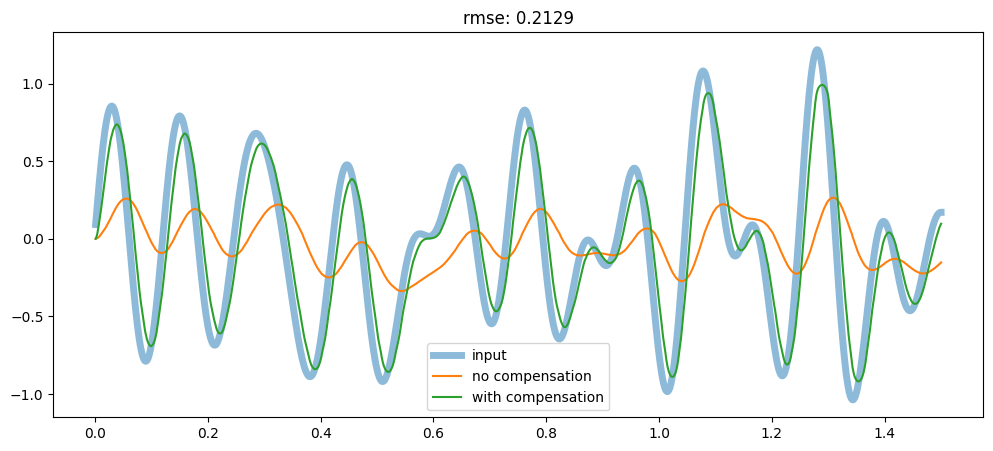

In [6]:
tau = 0.1
import nengo.utils.filter_design

model = nengo.Network()
with model:
    stim = nengo.Node(nengo.processes.WhiteSignal(period=5, high=10, rms=0.5, seed=3))
    p_stim = nengo.Probe(stim)
    
    a = nengo.Ensemble(n_neurons=100, dimensions=1)
    nengo.Connection(stim, a, synapse=tau)
    p_a = nengo.Probe(a)    
    
    
    precompensate = nengo.Ensemble(n_neurons=1000, dimensions=1, radius=2)
    A, B, C, D = nengo.utils.filter_design.tf2ss([tau, 1], [0.01, 1])
    
    nengo.Connection(stim, precompensate, transform=tau*B, synapse=tau)
    nengo.Connection(precompensate, precompensate, transform=tau*A+1, synapse=tau)
    d = nengo.Ensemble(n_neurons=100, dimensions=1)
    nengo.Connection(precompensate, d, transform=C, synapse=tau)
    nengo.Connection(stim, d, transform=D, synapse=tau)
    
    p_d = nengo.Probe(d)

for ens in model.all_ensembles:
    ens.neuron_type=nengo.LIFRate()
    
sim = nengo.Simulator(model, dt=0.001)
with sim:
    sim.run(1.5)
    
plt.figure(figsize=(12,5))
plt.plot(sim.trange(), sim.data[p_stim], label='input', lw=5, alpha=0.5)
plt.plot(sim.trange(), sim.data[p_a], label='no compensation')
plt.plot(sim.trange(), sim.data[p_d], label='with compensation')
rmse = np.sqrt(np.mean((sim.data[p_stim]-sim.data[p_d])**2))
plt.title(f'rmse: {rmse:1.4f}')

plt.legend()
plt.show()    
    
    
    


Success!  However, we need a fair number of neurons to do this.  And it's still not a great compensation.  How else can we do this?

Well, in general the task we're trying to do is to find a linear filter that undoes some transformation.  But, and LDN is an arbitrary n-th order linear filter.  So, all we need to do is to feed the filtered data into an LDN, and then solve for a decoder that would give us back the original unfiltered data.  Then, since it's all linear, we can use that same LDN and those decoders as a pre-filter.  Let's give that a try.


In [7]:
import scipy.linalg
from scipy.special import legendre

class LDN(nengo.Process):
    def __init__(self, theta, q, size_in=1):
        self.q = q              # number of internal state dimensions per input
        self.theta = theta      # size of time window (in seconds)
        self.size_in = size_in  # number of inputs

        # Do Aaron's math to generate the matrices A and B so that
        #  dx/dt = Ax + Bu will convert u into a legendre representation over a window theta
        #  https://github.com/arvoelke/nengolib/blob/master/nengolib/synapses/analog.py#L536
        A = np.zeros((q, q))
        B = np.zeros((q, 1))
        for i in range(q):
            B[i] = (-1.)**i * (2*i+1)
            for j in range(q):
                A[i,j] = (2*i+1)*(-1 if i<j else (-1.)**(i-j+1)) 
        self.A = A / theta
        self.B = B / theta        
        
        super().__init__(default_size_in=size_in, default_size_out=q*size_in)

    def make_step(self, shape_in, shape_out, dt, rng, state=None):
        state = np.zeros((self.q, self.size_in))

        # Handle the fact that we're discretizing the time step
        #  https://en.wikipedia.org/wiki/Discretization#Discretization_of_linear_state_space_models
        Ad = scipy.linalg.expm(self.A*dt)
        Bd = np.dot(np.dot(np.linalg.inv(self.A), (Ad-np.eye(self.q))), self.B)

        # this code will be called every timestep
        def step_legendre(t, x, state=state):
            state[:] = np.dot(Ad, state) + np.dot(Bd, x[None, :])
            return state.T.flatten()
        return step_legendre

    def get_weights_for_delays(self, r):
        # compute the weights needed to extract the value at time r
        # from the network (r=0 is right now, r=1 is theta seconds ago)
        r = np.asarray(r)
        m = np.asarray([legendre(i)(2*r - 1) for i in range(self.q)])
        return m.reshape(self.q, -1).T

Here we find the decoders from the LDN that should convert a filtered signal to an unfiltered one.

Note that we have 3 free parameters here:
 - LDN theta
 - LDN q
 - high (the upper freqency of the signal to train on)
 
Note that we want `high` to be higher frequency than the signals that it will eventually be used on, since precompensating will give us higher frequency signals than we started with.

In [8]:
tau = 0.1
signal = nengo.processes.WhiteSignal(high=20, period=20).run(20)
signal_f = nengo.synapses.Lowpass(tau).apply(signal)

ldn = LDN(theta=0.01, q=4)
signal_f_ldn = ldn.apply(signal_f)

dec, info = nengo.solvers.LstsqL2(reg=1e-2)(signal_f_ldn, signal)

C:\Users\terry\anaconda3\envs\py313\Lib\site-packages\nengo\cache.py:624: UserWarning: Decoder cache could not acquire lock and was deactivated.
  warnings.warn("Decoder cache could not acquire lock and was deactivated.")


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

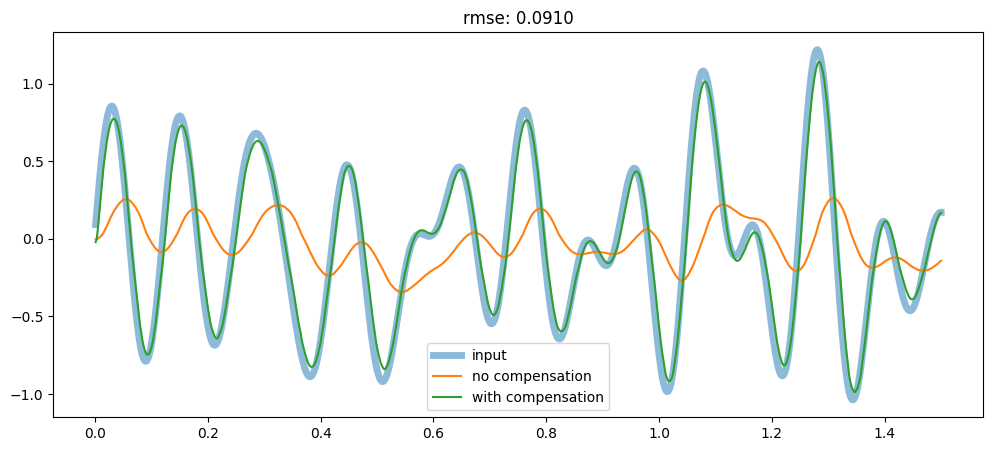

In [9]:
model = nengo.Network()
with model:
    stim = nengo.Node(nengo.processes.WhiteSignal(period=5, high=10, rms=0.5, seed=3))
    p_stim = nengo.Probe(stim)
    
    a = nengo.Ensemble(n_neurons=100, dimensions=1)
    nengo.Connection(stim, a, synapse=tau)
    p_a = nengo.Probe(a)    
    
    
    ldn_node = nengo.Node(ldn)
    nengo.Connection(stim, ldn_node, synapse=None)
    e = nengo.Ensemble(n_neurons=100, dimensions=1, radius=2)
    nengo.Connection(ldn_node, e, transform=dec.T, synapse=tau)
    
    p_e = nengo.Probe(e)

for ens in model.all_ensembles:
    ens.neuron_type=nengo.LIFRate()
    
sim = nengo.Simulator(model, dt=0.001)
with sim:
    sim.run(1.5)
    
plt.figure(figsize=(12,5))
plt.plot(sim.trange(), sim.data[p_stim], label='input', lw=5, alpha=0.5)
plt.plot(sim.trange(), sim.data[p_a], label='no compensation')
plt.plot(sim.trange(), sim.data[p_e], label='with compensation')
rmse = np.sqrt(np.mean((sim.data[p_stim]-sim.data[p_e])**2))
plt.title(f'rmse: {rmse:1.4f}')
plt.legend()
plt.show()    
    
    
    


It works!  And seems to have less time delay than the approach given above.  

But, that's using an ideal LDN.  What if we implement the LDN in neurons.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

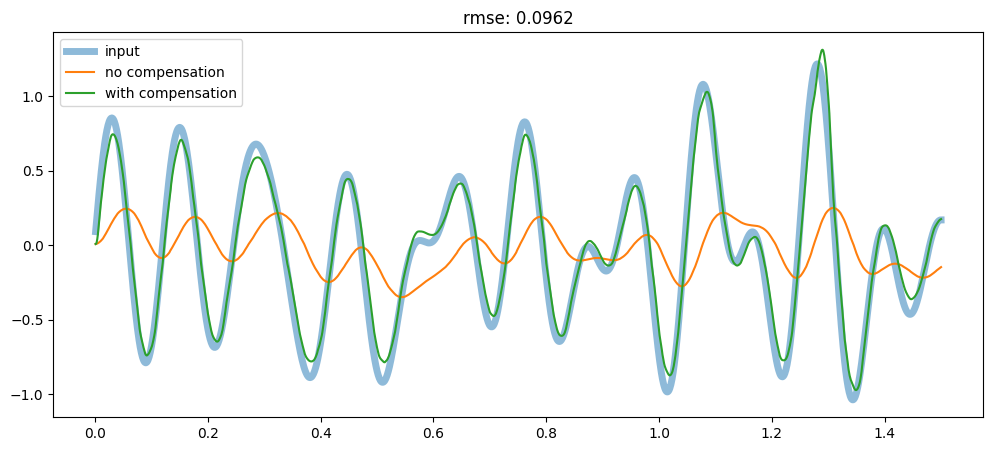

In [17]:
model = nengo.Network()
with model:
    stim = nengo.Node(nengo.processes.WhiteSignal(period=5, high=10, rms=0.5, seed=3))
    p_stim = nengo.Probe(stim)
    
    a = nengo.Ensemble(n_neurons=100, dimensions=1)
    nengo.Connection(stim, a, synapse=tau)
    p_a = nengo.Probe(a)    
    
    
    ldn_ens = nengo.networks.EnsembleArray(n_neurons=100, n_ensembles=ldn.q)
    nengo.Connection(stim, ldn_ens.input, synapse=tau, transform=tau*ldn.B)
    nengo.Connection(ldn_ens.output, ldn_ens.input, synapse=tau, transform=tau*ldn.A+np.eye(ldn.q))
    
    e = nengo.Ensemble(n_neurons=100, dimensions=1, radius=2)
    nengo.Connection(ldn_ens.output, e, transform=dec.T, synapse=tau)
    
    p_e = nengo.Probe(e)

for ens in model.all_ensembles:
    ens.neuron_type=nengo.LIFRate()
    
sim = nengo.Simulator(model, dt=0.001)
with sim:
    sim.run(1.5)
    
plt.figure(figsize=(12,5))
plt.plot(sim.trange(), sim.data[p_stim], label='input', lw=5, alpha=0.5)
plt.plot(sim.trange(), sim.data[p_a], label='no compensation')
plt.plot(sim.trange(), sim.data[p_e], label='with compensation')
rmse = np.sqrt(np.mean((sim.data[p_stim]-sim.data[p_e])**2))
plt.title(f'rmse: {rmse:1.4f}')
plt.legend()
plt.show()    
    
    
    


It still works!

Can we do even better?   The neuron LDN won't give exactly the same dynamics as the ideal LDN, so the decoders might be slightly sub-optimal.  What if we solve for the decoders based on the neural version?

In [24]:
tau = 0.1
seed = 856
signal = nengo.processes.WhiteSignal(high=20, period=20).run(20)
signal_f = nengo.synapses.Lowpass(tau).apply(signal)


model = nengo.Network()
with model:
    stim = nengo.Node(nengo.processes.WhiteSignal(period=20, high=20, rms=0.5))
    stim_f = nengo.Node(None, size_in=1)
    nengo.Connection(stim, stim_f, synapse=tau)
    p_stim = nengo.Probe(stim)
    
    ldn_ens = nengo.networks.EnsembleArray(n_neurons=100, n_ensembles=ldn.q, seed=seed, neuron_type=nengo.LIFRate())
    nengo.Connection(stim_f, ldn_ens.input, synapse=tau, transform=tau*ldn.B)
    nengo.Connection(ldn_ens.output, ldn_ens.input, synapse=tau, transform=tau*ldn.A+np.eye(ldn.q))
    p_ldn = nengo.Probe(ldn_ens.output)
sim = nengo.Simulator(model)
with sim:
    sim.run(20)
signal_f_ldn = sim.data[p_ldn]    
signal = sim.data[p_stim]

dec, info = nengo.solvers.LstsqL2(reg=1e-2)(signal_f_ldn, signal)

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

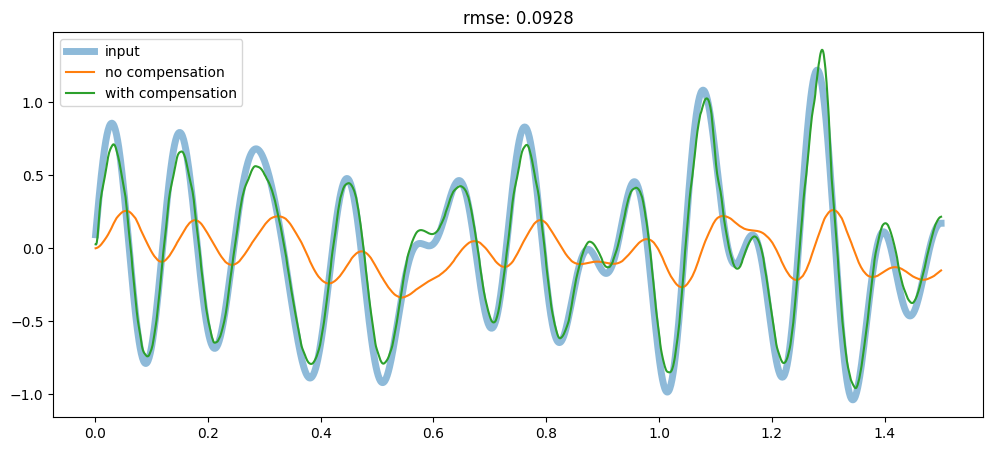

In [25]:
model = nengo.Network()
with model:
    stim = nengo.Node(nengo.processes.WhiteSignal(period=5, high=10, rms=0.5, seed=3))
    p_stim = nengo.Probe(stim)
    
    a = nengo.Ensemble(n_neurons=100, dimensions=1)
    nengo.Connection(stim, a, synapse=tau)
    p_a = nengo.Probe(a)    
    
    
    ldn_ens = nengo.networks.EnsembleArray(n_neurons=100, n_ensembles=ldn.q, seed=seed)
    nengo.Connection(stim, ldn_ens.input, synapse=tau, transform=tau*ldn.B)
    nengo.Connection(ldn_ens.output, ldn_ens.input, synapse=tau, transform=tau*ldn.A+np.eye(ldn.q))
    
    e = nengo.Ensemble(n_neurons=100, dimensions=1, radius=2)
    nengo.Connection(ldn_ens.output, e, transform=dec.T, synapse=tau)
    
    p_e = nengo.Probe(e)

for ens in model.all_ensembles:
    ens.neuron_type=nengo.LIFRate()
    
sim = nengo.Simulator(model, dt=0.001)
with sim:
    sim.run(1.5)
    
plt.figure(figsize=(12,5))
plt.plot(sim.trange(), sim.data[p_stim], label='input', lw=5, alpha=0.5)
plt.plot(sim.trange(), sim.data[p_a], label='no compensation')
plt.plot(sim.trange(), sim.data[p_e], label='with compensation')
plt.legend()
rmse = np.sqrt(np.mean((sim.data[p_stim]-sim.data[p_e])**2))
plt.title(f'rmse: {rmse:1.4f}')
plt.show()    
    
    
    


This might be slightly better, but it's hard to tell.  More experimentation needed!